In [4]:
import numpy as np
from tcn import TCN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, TimeDistributed, InputLayer
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical


In [43]:
import pandas as pd
import numpy as np

# 1. Load the file ------------------------------------------------------------
data = pd.read_excel("dv0_withoutstraw_sipCAdded.xlsx")    # ← path to your .xlsx
# df = data[data['Label'] == 1]
# ---------------------------------------------------------------------------
# 2) Column setup
feature_cols = df.columns[1:65]          # 64 Zone columns
seq_keys     = ["Participant_ID", "sip_id"]
label_col    = "dV"                      # regression target

# ---------------------------------------------------------------------------
# 3) Build the datasets
X, y_reg = [], []

for _, g in df.groupby(seq_keys, sort=False):
    # feature tensor for this sip
    X.append(g[feature_cols].to_numpy(dtype=np.float32))   # shape (frames, 64)
    # regression label (one per sip)
    y_reg.append(float(g[label_col].iloc[0]))

y_reg = np.asarray(y_reg,  dtype=np.float32)               # (num_sips,)

# ---------------------------------------------------------------------------
# 4) Classification label: always 1 (= drinking)
y_cls = np.ones_like(y_reg, dtype=np.float32)              # (num_sips,)

# Optional: combine both labels in one array if your model expects it
y_combined = np.column_stack([y_cls, y_reg])               # (num_sips, 2)

# ---------------------------------------------------------------------------
# X : list of variable-length arrays, each (frames, 64)
# y_reg : volume per sip
# y_cls : binary drinking flag (all ones)
# y_combined : [[1, dV₁], [1, dV₂], …]  ← handy for multi-task models

In [75]:
# ... [everything above, unchanged]

# --- Inspect the number of frames in each sip --------------------------------

# Number of frames per sip (same order as X/y_reg)
frames_per_sip = [x.shape[0] for x in X]

# Print some sample results:
for i, (frames, target) in enumerate(zip(frames_per_sip, y_reg)):
    print(f"Sip {i}: {frames} frames, dV={target}")
    # Optionally stop after a few samples
    if i >= 10:
        break

# To see **all** frame counts, you can also print the list
print("Frame counts for all sips:", frames_per_sip)

# --- Optionally: see distribution --------------------------------------------

print("Min frames in a sip:", np.min(frames_per_sip))
print("Max frames in a sip:", np.max(frames_per_sip))
print("Average frames per sip:", np.mean(frames_per_sip))
print("dV (y_reg) values for each sip:", y_reg)

Sip 0: 26 frames, dV=100.0
Sip 1: 26 frames, dV=80.0
Sip 2: 27 frames, dV=60.0
Sip 3: 29 frames, dV=40.0
Sip 4: 23 frames, dV=20.0
Sip 5: 13 frames, dV=100.0
Sip 6: 24 frames, dV=80.0
Sip 7: 21 frames, dV=60.0
Sip 8: 21 frames, dV=40.0
Sip 9: 27 frames, dV=20.0
Sip 10: 29 frames, dV=95.23809814453125
Frame counts for all sips: [26, 26, 27, 29, 23, 13, 24, 21, 21, 27, 29, 29, 20, 21, 16, 15, 16, 10, 10, 10, 7, 9, 9, 17, 8, 11, 8, 20, 27, 43, 60, 48, 29, 39, 17, 13, 11, 14, 12, 16, 15, 16, 20, 16, 14, 16, 11, 19, 19, 19, 16, 18, 28, 19, 21, 28, 14, 16, 15, 21, 15, 16, 19, 17, 19, 12, 19, 13, 13, 16, 16, 12, 13, 13, 14, 11, 16, 20, 20, 18, 17, 37, 17, 18, 18, 15, 19, 17, 23, 15, 21, 14, 13, 13, 12, 10, 12, 9, 12, 12, 12, 9, 13, 18, 13, 17, 19, 15, 15, 26, 11, 16, 17, 17, 21, 19, 17, 16, 12, 14, 11, 12, 8, 10, 10, 19, 15, 24, 20, 20, 19, 30, 18, 17, 12, 29, 21, 26, 17, 17, 29, 24, 33, 20, 24, 22, 15, 12, 14, 14, 15, 17, 17, 12, 32, 36, 29, 33, 30, 26, 25, 29, 30, 29, 28, 11, 10, 12, 11, 11

In [44]:
# file_path = "dv0_withoutstraw_sipCAdded.xlsx"
# data = pd.read_excel(file_path)

# # Encode labels
# le = LabelEncoder()
# data["Label"] = le.fit_transform(data["Label"])
# X = data.iloc[:, 1:65].values.astype("float32")
# y = data["Label"].values.astype("int8")

In [45]:
# test=data.head(500)
# test.to_excel('test.xlsx')

In [76]:
# X

In [77]:
# y_reg

In [60]:
# ===================== 1. imports & set-up ===================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tcn import TCN           # pip install keras-tcn --upgrade
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Reproducibility
rng = np.random.default_rng(seed=42)

# ===================== 2. load & group =======================================
df = pd.read_excel("dv0_withoutstraw_sipCAdded.xlsx")      # or test.xlsx
# df = data[data['Label'] == 1]
feature_cols = df.columns[1:65]            # 64 zone features
seq_keys     = ["Participant_ID", "sip_id"]
label_col    = "dV"                         # regression target

X, y = [], []
for _, g in df.groupby(seq_keys, sort=False):
    X.append(g[feature_cols].to_numpy(dtype=np.float32))   # (frames, 64)
    y.append(float(g[label_col].iloc[0]))                  # one value / sip
y = np.asarray(y, dtype=np.float32)

num_sips = len(X)
print(f"Total sips: {num_sips}")

# ===================== 3. shuffle sips & train/test split ====================
idx = np.arange(num_sips)
rng.shuffle(idx)

split_at = int(0.8 * num_sips) if num_sips > 1 else 1   # handle tiny datasets
train_idx, test_idx = idx[:split_at], idx[split_at:]

X_train = [X[i] for i in train_idx]
y_train = y[train_idx]
X_test  = [X[i] for i in test_idx]
y_test  = y[test_idx]

print(f"Train sips: {len(X_train)} | Test sips: {len(X_test)}")

# ===================== 4. build TCN that accepts variable length =============
# The input layer uses 'None' for the time dimension.
inp  = tf.keras.Input(shape=(None, 64), dtype=tf.float32)  # (T, 64)
x    = TCN(return_sequences=False)(inp)                    # (batch, filters)
out  = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inp, out)
model.compile(optimizer='adam', loss='mse')
model.summary()

# ===================== 5. data pipeline (no padding) =========================
def gen(xs, ys):
    """Yields one (sequence, label) pair at a time."""
    while True:
        order = rng.permutation(len(xs))
        for i in order:
            yield xs[i], ys[i]

batch_size = 1                      # one sip per batch → variable length ok
steps_per_epoch = len(X_train)
val_steps        = len(X_test)

train_ds = tf.data.Dataset.from_generator(
    lambda: gen(X_train, y_train),
    output_signature=(
        tf.TensorSpec(shape=(None, 64),  dtype=tf.float32),   # sequence
        tf.TensorSpec(shape=(),          dtype=tf.float32)    # scalar label
    )
).repeat().batch(batch_size)

val_ds = tf.data.Dataset.from_generator(
    lambda: gen(X_test, y_test),
    output_signature=(
        tf.TensorSpec(shape=(None, 64),  dtype=tf.float32),
        tf.TensorSpec(shape=(),          dtype=tf.float32)
    )
).repeat().batch(batch_size)

# ===================== 6. train =============================================
epochs = 20
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=val_steps,
    epochs=epochs,
    verbose=1
)

# ===================== 7. inference on test set =============================
y_pred = np.zeros_like(y_test)
for i, seq in enumerate(X_test):
    y_pred[i] = model.predict(seq[None, ...], verbose=0)  # add batch axis

# evaluation
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)
print(f"Test RMSE: {rmse:.2f} | R²: {r2:.3f}")

# ===================== 8. plot results ======================================
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, color="dodgerblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=1)
plt.xlabel("True dV")
plt.ylabel("Predicted dV")
plt.title("TCN Regression per Sip")
plt.grid(True)
plt.tight_layout()
plt.show()

Total sips: 156
Train sips: 124 | Test sips: 32


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_5 (TCN)                     │ (None, 64)             │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,289 (579.25 KB)

 Trainable params: 148,289 (579.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: nan - val_loss: nan
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: nan - val_loss: nan
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: nan - val_loss: nan
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: nan - val_loss: nan
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: nan - val_loss: nan
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: nan - val_loss: nan
Epoch 9/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 10/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 11/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 12/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan
Epoch 13/20
124/124 ━━━━━━━━━━━━━━━━━

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_42642/1441184164.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred[i] = model.predict(seq[None, ...], verbose=0)  # add batch axis
/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


ValueError: Input contains NaN.

In [62]:
import pandas as pd
import numpy as np

df = pd.read_excel("dv0_withoutstraw_sipCAdded.xlsx")

print("Any NaN in feature columns:", df.iloc[:, 1:65].isnull().values.any())
print("Any NaN or Inf in dV:", df['dV'].isnull().any() or np.isinf(df['dV']).any())
print(df['dV'].describe())  # See if weird values are present

Any NaN in feature columns: False
Any NaN or Inf in dV: False
count    36201.000000
mean        21.381609
std         36.723890
min          0.000000
25%          0.000000
50%          0.000000
75%         39.682540
max        100.000000
Name: dV, dtype: float64


INFO:tensorflow:Enabled check-numerics callback in thread MainThread
Total sips: 446
Train 356   Test 90


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_18 (TCN)                    │ (None, 64)             │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,289 (579.25 KB)

 Trainable params: 148,289 (579.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 19.7551 - val_loss: 5.0877
Epoch 2/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1658 - val_loss: 1.5274
Epoch 3/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.7094 - val_loss: 1.2638
Epoch 4/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4068 - val_loss: 0.6031
Epoch 5/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5551 - val_loss: 0.5560
Epoch 6/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3626 - val_loss: 0.2499
Epoch 7/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2529 - val_loss: 0.1661
Epoch 8/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2757 - val_loss: 0.1250
Epoch 9/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1873 - val_loss: 0.1397
Epoch 10/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1387 - val_loss: 0.1047
Epoch 11/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0899 - val_loss: 0.1031
Epoch 12/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


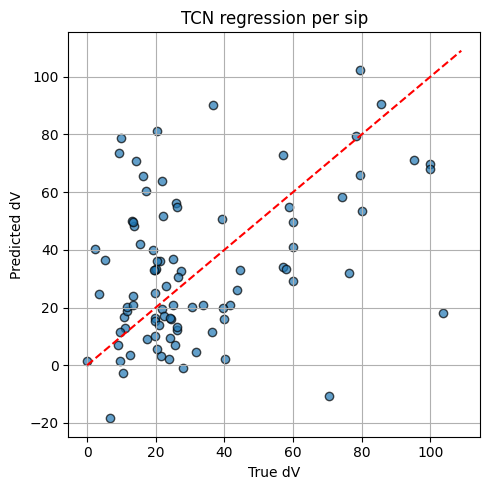

In [88]:
# ------------------------------------------------------------
# 0. imports & reproducibility
# ------------------------------------------------------------
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()       # raises if any op produces NaN/Inf

# ------------------------------------------------------------
# 1. load  ➜ X(list of (T,64)), y(array)
# ------------------------------------------------------------
# df = pd.read_excel("dv0_withoutstraw_sipCAdded.xlsx")      # or test.xlsx
feature_cols = df.columns[1:65]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
for _, g in df.groupby(seq_keys, sort=False):
    X.append(g[feature_cols].to_numpy(dtype=np.float32))   # (frames,64)
    y.append(float(g[label_col].iloc[0]))
y = np.asarray(y, np.float32)
print("Total sips:", len(X))

# ------------------------------------------------------------
# 2. shuffle whole sips  ➜ 80/20 split
# ------------------------------------------------------------
idx = rng.permutation(len(X))
split = int(.8*len(X))
tr_idx, te_idx = idx[:split], idx[split:]
X_tr = [X[i] for i in tr_idx];  y_tr = y[tr_idx]
X_te = [X[i] for i in te_idx];  y_te = y[te_idx]
print(f"Train {len(X_tr)}   Test {len(X_te)}")

# ------------------------------------------------------------
# 3. NORMALISE FEATURES  (fit on training only!)
# ------------------------------------------------------------
mat_tr   = np.vstack(X_tr)              # stack all frames → (∑T,64)
mean64   = mat_tr.mean(axis=0, keepdims=True)
std64    = mat_tr.std(axis=0,  keepdims=True) + 1e-8       # avoid /0

def norm(seq): return (seq - mean64) / std64
X_tr = [norm(s) for s in X_tr]
X_te = [norm(s) for s in X_te]

# optional: scale labels to 0-1 (helpful when dV max≈100)
y_max = y_tr.max() or 1.               # guard max=0
y_tr_s = y_tr / y_max
y_te_s = y_te / y_max

# ------------------------------------------------------------
# 4. dataset generator  (batch_size=1 keeps variable length)
# ------------------------------------------------------------
def make_ds(xs, ys):
    ds = tf.data.Dataset.from_generator(
        lambda: ((x, y) for x, y in zip(xs, ys)),
        output_signature=(
            tf.TensorSpec(shape=(None, 64), dtype=tf.float32),
            tf.TensorSpec(shape=(),        dtype=tf.float32))
    )
    return ds.shuffle(len(xs)).repeat().batch(1)

train_ds = make_ds(X_tr, y_tr_s)
test_ds  = make_ds(X_te, y_te_s)

# ------------------------------------------------------------
# 5. model  (smaller LR + grad-clipping)
# ------------------------------------------------------------
inputs  = tf.keras.Input(shape=(None, 64))
x       = TCN(return_sequences=False)(inputs)
outputs = tf.keras.layers.Dense(1)(x)
model   = tf.keras.Model(inputs, outputs)

opt = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
model.compile(opt, loss='mse')
model.summary()

steps_per_epoch = len(X_tr)
val_steps       = len(X_te)
hist = model.fit(train_ds,
                 epochs=30,
                 steps_per_epoch=steps_per_epoch,
                 validation_data=test_ds,
                 validation_steps=val_steps,
                 verbose=1)

# ------------------------------------------------------------
# 6. evaluation (un-scale predictions)
# ------------------------------------------------------------
y_pred_s = np.array([model.predict(x[None,...], verbose=0)[0,0] for x in X_te])
y_pred   = y_pred_s * y_max

rmse = mean_squared_error(y_te, y_pred, squared=False)
r2   = r2_score(y_te, y_pred)
print(f"Test RMSE = {rmse:.2f}   R² = {r2:.3f}")

# ------------------------------------------------------------
# 7. plot
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
plt.scatter(y_te, y_pred, alpha=.7, edgecolor='k')
lims = [0, max(y_te.max(), y_pred.max())*1.05]
plt.plot(lims, lims, 'r--')
plt.xlabel("True dV"); plt.ylabel("Predicted dV")
plt.title("TCN regression per sip")
plt.grid(True); plt.tight_layout(); plt.show()

In [2]:
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    # "dv0_withoutstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")

# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())

previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62

Merged dataframe shape: (79370, 82)
Global Participant_ID range: 6 … 62


In [5]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================
df = df[df["Label"] == 1]                        # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:                                # ← drop empty sip
        skip_count += 1
        continue
    X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
    y.append(dV)

y = np.asarray(y, np.float32)
X = np.array(X, dtype=object)   # each element is still a (T,64) array
print(f"Total sips kept : {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", y.min(), "max:", y.max())

Total sips kept : 313
Zero-volume skipped : 2
Label stats  → min: 1.4691479 max: 160.2


In [82]:
df = df_all

In [83]:
print("Label stats  (raw, before scaling)")
print("  min :", y.min())
print("  #zeros :", (y == 0).sum())
print("  any negative? ", (y < 0).any())

Label stats  (raw, before scaling)
  min : 19.047619
  #zeros : 0
  any negative?  False


INFO:tensorflow:Enabled check-numerics callback in thread MainThread
Total sips kept : 443
Zero-volume skipped : 3
Label stats  → min: 1.4691479 max: 160.2
Train 354   Test 89


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_17 (TCN)                    │ (None, 64)             │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,289 (579.25 KB)

 Trainable params: 148,289 (579.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4.7319 - val_loss: 0.0656
Epoch 2/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11.5101 - val_loss: 0.1897
Epoch 3/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4171 - val_loss: 0.0580
Epoch 4/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1481 - val_loss: 0.0822
Epoch 5/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8120 - val_loss: 4.8029
Epoch 6/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.3018 - val_loss: 0.0917
Epoch 7/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1373 - val_loss: 0.0726
Epoch 8/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1004 - val_loss: 0.0240
Epoch 9/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0509 - val_loss: 0.0265
Epoch 10/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1313 - val_loss: 0.0184
Epoch 11/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0204 - val_loss: 0.0223
Epoch 12/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

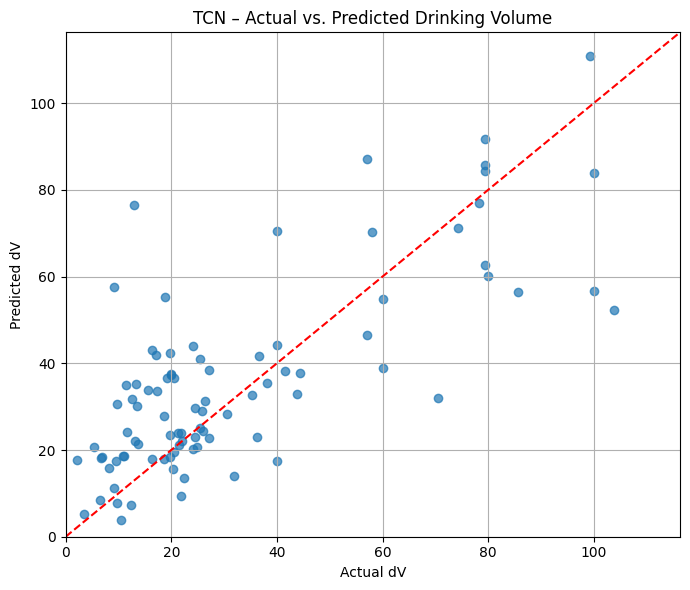

In [87]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score

rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 1                                   # 1 = ragged, >1 = padded

# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================
df = df[df["Label"] == 1]                        # keep only annotated frames

feature_cols = df.columns[1:65]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:                                # ← drop empty sip
        skip_count += 1
        continue
    X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
    y.append(dV)

y = np.asarray(y, np.float32)

print(f"Total sips kept : {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", y.min(), "max:", y.max())

# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split = int(.8 * len(X))
X_tr, y_tr = [X[i] for i in idx[:split]], y[idx[:split]]
X_te, y_te = [X[i] for i in idx[split:]], y[idx[split:]]
print(f"Train {len(X_tr)}   Test {len(X_te)}")

# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_tr = np.vstack(X_tr)
mean64 = mat_tr.mean(0, keepdims=True)
std64  = mat_tr.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_tr = [norm(s) for s in X_tr]
X_te = [norm(s) for s in X_te]

# label scaling
y_max  = y_tr.max() or 1.
y_tr_s = y_tr / y_max
y_te_s = y_te / y_max

# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_tr, y_tr_s, shuffle=True)
test_ds  = make_ds(X_te, y_te_s, shuffle=False)

# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x   = TCN(return_sequences=False)(inp)
out = tf.keras.layers.Dense(1, activation="softplus")(x)   # non-negative
model = tf.keras.Model(inp, out)

model.compile(tf.keras.optimizers.Adam(3e-4, clipnorm=1.0), loss="mse")
model.summary()

steps_per_epoch = len(X_tr) // BATCH + (len(X_tr) % BATCH > 0)
val_steps       = len(X_te) // BATCH + (len(X_te) % BATCH > 0)

model.fit(train_ds,
          epochs=50,
          steps_per_epoch=steps_per_epoch,
          validation_data=test_ds,
          validation_steps=val_steps,
          verbose=1)

# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_te])
y_pred = y_pred_s * y_max

# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_te, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_pred)

non_zero = y_te != 0
rmspe = (np.sqrt(np.mean(((y_te[non_zero]-y_pred[non_zero]) /
                          y_te[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_te)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_te, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))

# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_te, y_pred, alpha=0.7)
lims = [0, max(y_te.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.tight_layout(); plt.show()

In [79]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================

feature_cols = df.columns[1:65]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])        # one label per sip

    if dV == 0.0:                           # ← skip zero-volume sip
        skip_count += 1
        continue

    X.append(g[feature_cols].to_numpy(dtype=np.float32))   # (T,64)
    y.append(dV)

y = np.asarray(y, np.float32)

print(f"Total sips kept : {len(X)}")
print(f"Zero-volume sips skipped : {skip_count}")
print("Label stats →  min:", y.min(), "max:", y.max(),
      "any zero?", (y == 0).any())

Total sips kept : 443
Zero-volume sips skipped : 3
Label stats →  min: 1.4691479 max: 160.2 any zero? False


INFO:tensorflow:Enabled check-numerics callback in thread MainThread
Total sips: 446
Train 356   Test 90


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_12 (TCN)                    │ (None, 64)             │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,289 (579.25 KB)

 Trainable params: 148,289 (579.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 16.3422 - val_loss: 3.2876
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.2443 - val_loss: 1.6895
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6902 - val_loss: 1.0194
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1981 - val_loss: 0.8376
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6728 - val_loss: 0.4293
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4652 - val_loss: 0.4487
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3734 - val_loss: 0.4101
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3813 - val_loss: 0.1770
Epoch 9/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2553 - val_loss: 0.1544
Epoch 10/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1616 - val_loss: 0.1332
Epoch 11/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1971 - val_loss: 0.0899
Epoch 12/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

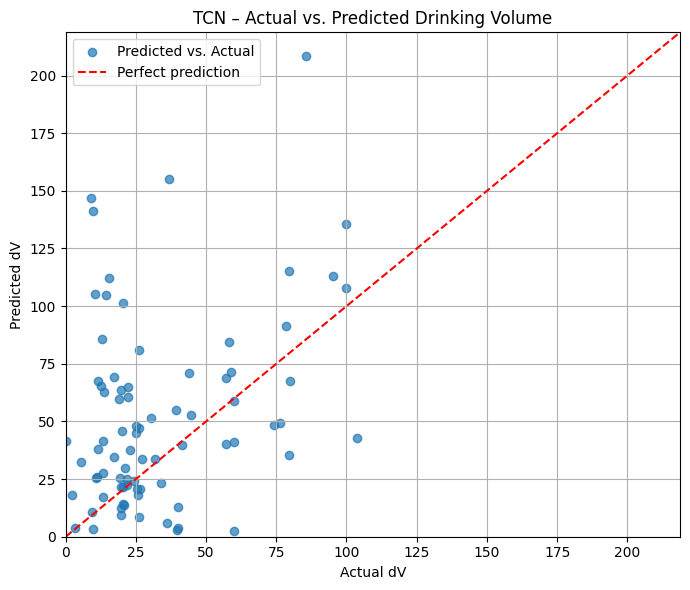

In [72]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()    # crash early on NaN/Inf

# ====================================================================
# 1. load data ➜ X(list of (T,64)), y(array)
# ====================================================================
# data = pd.read_excel("dv0_withoutstraw_sipCAdded.xlsx")      # or test.xlsx
df = df[df['Label'] == 1]
feature_cols = df.columns[1:65]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
for _, g in df.groupby(seq_keys, sort=False):
    X.append(g[feature_cols].to_numpy(dtype=np.float32))   # (frames,64)
    y.append(float(g[label_col].iloc[0]))
y = np.asarray(y, np.float32)
print("Total sips:", len(X))

# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split = int(.8 * len(X))
X_tr, y_tr = [X[i] for i in idx[:split]], y[idx[:split]]
X_te, y_te = [X[i] for i in idx[split:]], y[idx[split:]]
print(f"Train {len(X_tr)}   Test {len(X_te)}")

# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_tr = np.vstack(X_tr)                     # (ΣT, 64)
mean64 = mat_tr.mean(axis=0, keepdims=True)
std64  = mat_tr.std(axis=0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_tr = [norm(s) for s in X_tr]
X_te = [norm(s) for s in X_te]

# optional label scaling (keeps gradients in a nice range)
y_max  = y_tr.max() or 1.
y_tr_s = y_tr / y_max
y_te_s = y_te / y_max

# ====================================================================
# 4. data pipeline –––––––––––––––––––––––––––––––––––––––––––––––––––
#    Set BATCH=1  ➜ ragged batches (no padding)
#        BATCH>1  ➜ automatic zero-padding within each mini-batch
# ====================================================================
BATCH = 2          # <── change this number only

def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec(shape=(None, 64), dtype=tf.float32),
    tf.TensorSpec(shape=(),         dtype=tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: generator(xs, ys), output_signature=output_sig
    )
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        ds = ds.repeat().batch(1)                       # ragged → dense inside Keras
    else:
        ds = ds.repeat().padded_batch(
            BATCH,
            padded_shapes=([None, 64], []),
            padding_values=(0.0, 0.0)
        )
    return ds

train_ds = make_ds(X_tr, y_tr_s, shuffle=True)
test_ds  = make_ds(X_te, y_te_s, shuffle=False)

# ====================================================================
# 5. model
# ====================================================================
inp  = tf.keras.Input(shape=(None, 64))   # time dimension = None
x    = TCN(return_sequences=False)(inp)
out  = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inp, out)

opt = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
model.compile(opt, loss='mse')
model.summary()

steps_per_epoch = len(X_tr) // BATCH + (len(X_tr) % BATCH > 0)
val_steps       = len(X_te) // BATCH + (len(X_te) % BATCH > 0)

hist = model.fit(train_ds,
                 epochs=30,
                 steps_per_epoch=steps_per_epoch,
                 validation_data=test_ds,
                 validation_steps=val_steps,
                 verbose=1)

# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_te])
y_pred = y_pred_s * y_max           # back to real units

# ====================================================================
# 7. evaluation metrics
# ====================================================================
mse  = mean_squared_error(y_te, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_pred)

non_zero = y_te != 0
rmspe = (
    np.sqrt(np.mean(((y_te[non_zero] - y_pred[non_zero]) / y_te[non_zero]) ** 2)) * 100
    if non_zero.any() else np.nan
)

print(f"\nEvaluation on {len(y_te)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_te, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))

# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_te, y_pred, alpha=0.7, label="Predicted vs. Actual")
lims = [0, max(y_te.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

In [12]:


# Settings
num_sequences = 10  # Number of example sequences (batch size)
sequence_length = 5  # 5 frames per gesture
frame_height = 8
frame_width = 8

# Simulate random data (replace with your sensor data later)
# X = np.random.rand(num_sequences, sequence_length, frame_height, frame_width)
# y = np.random.rand(num_sequences, 1)  # Regression targets (volume drunk), one per sequence

# Model definition
model = Sequential([
    InputLayer(input_shape=(sequence_length, frame_height, frame_width)),
    TimeDistributed(Flatten()),         # Flatten each frame to a vector (8x8 -> 64)
    TCN(return_sequences=False),        # TCN over time dimension
    Dense(1)                            # Regression output
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train example (just for demonstration; in real use feed your actual data)
model.fit(X, y, epochs=3)

# Predict on new random test sequence
test_sequence = np.random.rand(1, sequence_length, frame_height, frame_width)
predicted_volume = model.predict(test_sequence)
print("Predicted volume drunk:", predicted_volume)

/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, 5, 64)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 64)             │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,289 (579.25 KB)

 Trainable params: 148,289 (579.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 64), dtype=float32). Expected shape (None, 5, 8, 8), but input has incompatible shape (None, 64)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 64), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [2]:
print(X)

[[[[0.33656399 0.49699363 0.80825979 ... 0.56105347 0.61209892
    0.04742416]
   [0.57817245 0.0909305  0.39749561 ... 0.08309654 0.99928155
    0.56570982]
   [0.80365331 0.97309392 0.06055443 ... 0.52606017 0.95046425
    0.4616116 ]
   ...
   [0.68126735 0.96080484 0.69489711 ... 0.56131133 0.89917023
    0.48378916]
   [0.55241086 0.83266467 0.93507392 ... 0.11570565 0.48150838
    0.02088448]
   [0.84766456 0.98379243 0.84775843 ... 0.18529185 0.18492353
    0.20959504]]

  [[0.16376223 0.18819211 0.20126319 ... 0.27343057 0.76917302
    0.10354398]
   [0.06876656 0.80709863 0.83006123 ... 0.72024857 0.45756503
    0.14858193]
   [0.26318402 0.99393242 0.81898322 ... 0.33871985 0.11686025
    0.30768916]
   ...
   [0.10882345 0.78971465 0.78183605 ... 0.79784416 0.28176966
    0.62902306]
   [0.13442674 0.65636331 0.98166771 ... 0.30265627 0.0950943
    0.24233237]
   [0.54827521 0.37294835 0.98286825 ... 0.12532204 0.75222413
    0.47722696]]

  [[0.06086873 0.00871976 0.5341949

In [3]:
print(y)

[[0.48192882]
 [0.09789282]
 [0.32883295]
 [0.18966243]
 [0.9041295 ]
 [0.94175406]
 [0.02897793]
 [0.29548045]
 [0.23298438]
 [0.35238058]]
